# **Rapid Express: Análisis de Perfil, Desempeño y Absentismo Laboral**
**(Basado en el dataset interno de incidencias de Recursos Humanos)**

---
### **Exploratory Data Analysis (EDA)**

**Equipo 28 | Analistas:** Emilio, Nuria (Perfil y Desempeño) y Andrea, Ana (Absentismo y Bienestar)

**Objetivos de este Notebook:**
De acuerdo con las instrucciones del proyecto y la estructura de nuestro tablero Kanban, en esta fase trabajaremos exclusivamente con los datos en su formato original (Raw Data). El objetivo es:
1. **Generar resúmenes estadísticos** de las variables nativamente numéricas.
2. **Crear visualizaciones iniciales** para identificar tendencias, distribuciones y anomalías (outliers) en el absentismo.
3. **Detectar correlaciones** entre las variables operativas y sociodemográficas disponibles.

*Nota técnica:* Las transformaciones de tipos de datos (como la conversión de variables categóricas o formatos de texto a numéricos) se han delegado al ticket posterior de **Data Cleaning**.

### Instalación de librerias

In [82]:
!pip install mysql-connector-python


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\NURIA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Importación de bibliotecas

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Configuración estética para gráficos de nivel profesional
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')# Ocultar advertencias menores para un notebook más limpio

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


### Conexión a Base de Datos y Extracción Inicial
Para asegurar que nuestro análisis sea escalable y consuma siempre los datos más actualizados, hemos automatizado la ingesta conectando el entorno directamente al servidor **MySQL** de la compañía en lugar de usar extracciones manuales en CSV.

In [84]:
import mysql.connector
import pandas as pd

config = {
    'host': '212.227.90.6',
    'user': 'Equipo28',
    'password': 'E1q2u3i4p5o28',
    'database': 'Equip_28'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

print("Tablas encontradas:")
for t in tablas:
    print(f" -> {t[0]}")
    globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)
    
cursor.close()
conn.close()

--- Conectado a la base de datos: Equip_28 ---
Tablas encontradas:
 -> RRHH
 -> vista_duplicados_exactos


In [85]:
df_RRHH=RRHH.copy()

In [86]:
df_RRHH.shape

(740, 21)

### Descripción de las variables del dataset

El conjunto contiene más de **740 registros y 21 columnas** con atributos como edad, ocupación, estado civil, nivel educativo, saldo y variables de contacto con el banco.  

- **ID** (id):identificación única del empleado
- **reason_absence** (razón de absentismo): razón de la ausencia al trabajo. Ausencias certificadas según la Clasificación Internacional de Enfermedades (CIE o  CID en inglés), estratificadas en 21 categorías, y 7 categorías adicionales sin CIE: seguimiento del paciente (22), consulta médica (23), donación de sangre (24), examen de laboratorio (25), ausencia injustificada (26), fisioterapia (27) y consulta odontológica (28).  CATEGÓRICA
- **month_absence** (mes de absentismo): mes en el que el empleado se ausenta del trabajo .  TEMPORAL
- **Day_week** (dia de la semana): Dia de la semana en que se producce la ausencia.  TEMPORAL
- **Seasons** (estación del año): estación en que se produce la ausencia (Verano (1), Otoño (2), Invierno(3), Primavera (4)). TEMPORAL
- **Transportation_expense** (gastos de transporte): gastos de transporte del empleado.  NUMÉRICA
- **Distance_Residence_Work** (distancia): distancia en km entre la residencia y el lugar de trabajo.  NUMÉRICA
- **Service_time** (antigüedad): tiempo de servicio o antigüedad del empleado en la empresa.  NUMÉRICA
- **Age** (edad): edad del empleado.  NUMÉRICA
- **Work_load_Average_day** (carga media diaria): carga de trabajo promedio por día.  NUMÉRICA
- **Hit_target** (cumplimiento del objetivo de desempeño): indica el porcentage alcanzado del objetivo establecido. NUMÉRICA  
- **Disciplinary_failure** (sanción disciplinaria): indica si el empleado ha tenido sanciones disciplinarias (sí=1/no=0). CATEGÓRICA
- **Education** (nivel educativo): nivel educativo del empleado (Bachillerato (1),graduado (2),postgraduado (3),master/doctorado (4)).  CATEGÓRICA
- **Son** (núm de hijos): Número de hijos.  NUMÉRICA
- **Social_drinker** (consumo de alcohol): indica si el empleado consume alcohol (sí=1/no=0).  CATEGÓRICA
- **Social_smoker** (fumador): indica si el empleado consume tabaco (sí=1/no=0). CATEGÓRICA
- **Pet** (mascotas): indica el número de mascotas del empleado.  NUMÉRICA
- **Weight** (peso): peso del empleado. NUMÉRICA
- **Height** (altura): altura del empleado.  NUMÉRICA
- **Body_mass_index** (Indice de masa corporal): relación entre peso y altura del empleado. NUMÉRICA
- **Absenteeism_hours** (horas de absentismo): número de horas de ausencia del empleado. NUMÉRICA

Limitación del dataset:  
Únicamente registra los empleados con absentismo

### Información general del dataset

In [87]:
df_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       740 non-null    int64 
 1   Reason_absence           740 non-null    int64 
 2   Month_absence            740 non-null    int64 
 3   Day_week                 740 non-null    int64 
 4   Seasons                  740 non-null    int64 
 5   Transportation_expense   740 non-null    int64 
 6   Distance_Residence_Work  740 non-null    int64 
 7   Service_time             740 non-null    int64 
 8   Age                      740 non-null    int64 
 9   Work_load_Average_day    740 non-null    object
 10  Hit_target               740 non-null    int64 
 11  Disciplinary_failure     740 non-null    object
 12  Education                740 non-null    object
 13  Son                      740 non-null    object
 14  Social_drinker           740 non-null    o

In [88]:
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,2,0,6,2,3,235,29,12,48,"275,089",...,1,1,1,0,1,5,88,163,33,0
736,21,0,6,2,3,268,11,8,33,"275,089",...,1,2,0,0,0,0,79,178,25,0
737,4,0,0,3,1,118,14,13,40,"271,219",...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,"271,219",...,0,1,2,1,0,2,100,170,35,0


In [89]:
df1=df_RRHH[df_RRHH['Reason_absence']==0]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 696 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       43 non-null     int64 
 1   Reason_absence           43 non-null     int64 
 2   Month_absence            43 non-null     int64 
 3   Day_week                 43 non-null     int64 
 4   Seasons                  43 non-null     int64 
 5   Transportation_expense   43 non-null     int64 
 6   Distance_Residence_Work  43 non-null     int64 
 7   Service_time             43 non-null     int64 
 8   Age                      43 non-null     int64 
 9   Work_load_Average_day    43 non-null     object
 10  Hit_target               43 non-null     int64 
 11  Disciplinary_failure     43 non-null     object
 12  Education                43 non-null     object
 13  Son                      43 non-null     object
 14  Social_drinker           43 non-null     objec

In [90]:
missing_values = df_RRHH.isna().sum()
print("El número de valores faltantes es:\n", missing_values)

El número de valores faltantes es:
 ID                         0
Reason_absence             0
Month_absence              0
Day_week                   0
Seasons                    0
Transportation_expense     0
Distance_Residence_Work    0
Service_time               0
Age                        0
Work_load_Average_day      0
Hit_target                 0
Disciplinary_failure       0
Education                  0
Son                        0
Social_drinker             0
Social_smoker              0
Pet                        0
Weight                     0
Height                     0
Body_mass_index            0
Absenteeism_hours          0
dtype: int64


In [91]:
duplicados = df_RRHH.duplicated().sum() #Contar el número total de filas duplicadas (exceptuando la primera ocurrencia)
print(f'El número de duplicados es {duplicados}')

El número de duplicados es 34


In [92]:
df_duplicated= df_RRHH[df_RRHH.duplicated(keep=False)]
df_duplicated

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
91,10,22,12,4,4,361,52,3,28,"261,306",...,0,1,1,1,0,4,80,172,27,8
92,10,22,12,4,4,361,52,3,28,"261,306",...,0,1,1,1,0,4,80,172,27,8
345,34,23,10,3,4,118,10,10,37,"253,465",...,0,1,0,0,0,0,83,172,28,3
348,34,23,10,3,4,118,10,10,37,"253,465",...,0,1,0,0,0,0,83,172,28,3
379,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
383,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
384,3,27,2,6,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
386,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
387,3,27,2,6,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
388,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3


In [93]:
df1=df_RRHH[df_RRHH['Month_absence']==0]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 737 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       3 non-null      int64 
 1   Reason_absence           3 non-null      int64 
 2   Month_absence            3 non-null      int64 
 3   Day_week                 3 non-null      int64 
 4   Seasons                  3 non-null      int64 
 5   Transportation_expense   3 non-null      int64 
 6   Distance_Residence_Work  3 non-null      int64 
 7   Service_time             3 non-null      int64 
 8   Age                      3 non-null      int64 
 9   Work_load_Average_day    3 non-null      object
 10  Hit_target               3 non-null      int64 
 11  Disciplinary_failure     3 non-null      object
 12  Education                3 non-null      object
 13  Son                      3 non-null      object
 14  Social_drinker           3 non-null      object

In [94]:
df_RRHH.nunique()

ID                         36
Reason_absence             28
Month_absence              13
Day_week                    5
Seasons                     4
Transportation_expense     24
Distance_Residence_Work    25
Service_time               18
Age                        22
Work_load_Average_day      38
Hit_target                 13
Disciplinary_failure        2
Education                   4
Son                         5
Social_drinker              2
Social_smoker               2
Pet                         6
Weight                     26
Height                     14
Body_mass_index            17
Absenteeism_hours          19
dtype: int64

In [95]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')

In [96]:
cols = ['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'] # Columns to check for unique values

for col in cols:
    print(f"\n{col}:")
    print(df_RRHH[col].unique())


ID:
[14 36  9 28 11 13 34 22 26 20 10 15 17 24  3 18  7  1 30  5  6  2 31 27
 33 23 21 25 12 32 16 29 19  8  4 35]

Reason_absence:
[11 13  6  9 12 19 18  1 10 14  7 28  2 26 23 22 21 24 17  8  5 15  4 25
  3 27 16  0]

Month_absence:
[11  4  7  3  6 12 10  5  8  9  1  2  0]

Day_week:
[2 4 3 6 5]

Seasons:
[4 3 1 2]

Transportation_expense:
[155 118 228 225 289 369 179 300 260 361 291 246 330 279 235 157 189 388
 184 248 378 268 233 231]

Distance_Residence_Work:
[12 13 14 26 36 17 10 50 52 31 22 25 51 16  5 11 27 20 29 15 42 49 48 35
 45]

Service_time:
[14 18 16  9 13 12 10 11  3 17  4  6  7  8  1 29 24 15]

Age:
[34 50 58 28 33 31 37 30 43 36 40 41 38 39 29 48 27 47 32 49 46 53]

Work_load_Average_day:
['284,031' '239,409' '264,604' '230,290' '222,196' '377,550' '280,549'
 '261,306' '265,017' '237,656' '326,452' '239,554' '205,917' '306,345'
 '343,253' '294,217' '253,957' '241,476' '275,312' '330,061' '378,884'
 '251,818' '268,519' '313,532' '246,288' '275,089' '253,465' '244,387'

**Observaciones generales:**
- No se observan valores nulos (NaN)
- Número de duplicados
- Hay 43 registros con Reason_absence=0 (no se conoce la razón)
- Hay 3 resgistros con Month_absence=0 (incongruente)
- La razón de absentismo es numérica en el dataset, pero en realidad corresponde a un valor categórico
- Mes/Dia/Estación de absentismo es numérica pero corresponde a un valor temporal o categórico
- Variables numéricas:  
    a) Transportation_expense, Distance_Residence_Work, Service_time, Age, Hit_target, Weight, Height, Body_mass_index, Absenteeism_hours  
    b) Pet y Son no lo son y deberian serlo
- Variables categóricas:  
    a) Education
    b) Reason_absence deberia serlo

**ANALISIS DEMOGRÁFICO INICIAL**

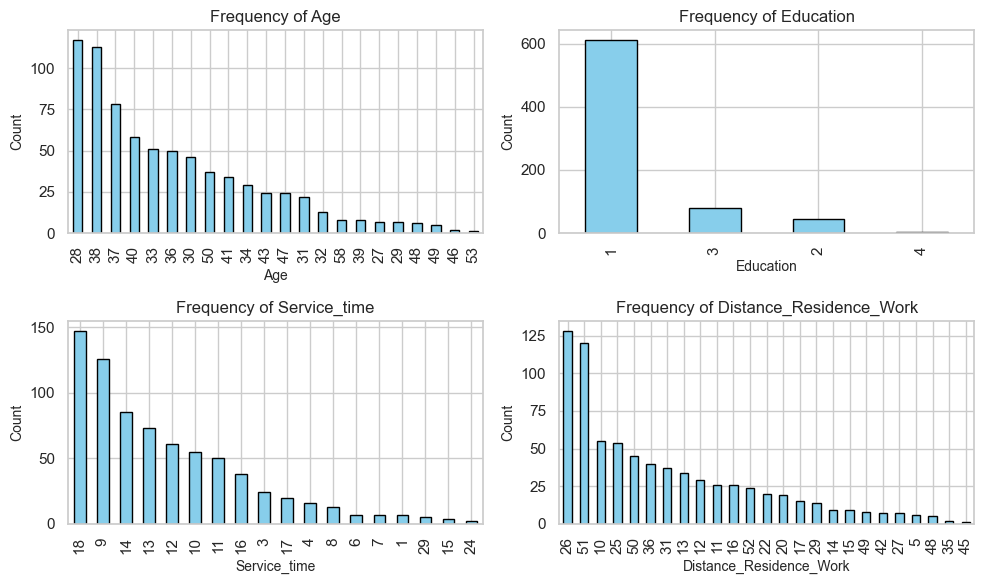

In [97]:
cols = ["Age","Education", 'Service_time', 'Distance_Residence_Work']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

axes = axes.flatten()  # 👈 convertir a lista de 4 posiciones

for i, col in enumerate(cols):
    freq = df_RRHH[col].value_counts()
    freq.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    
    axes[i].set_title(f'Frequency of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

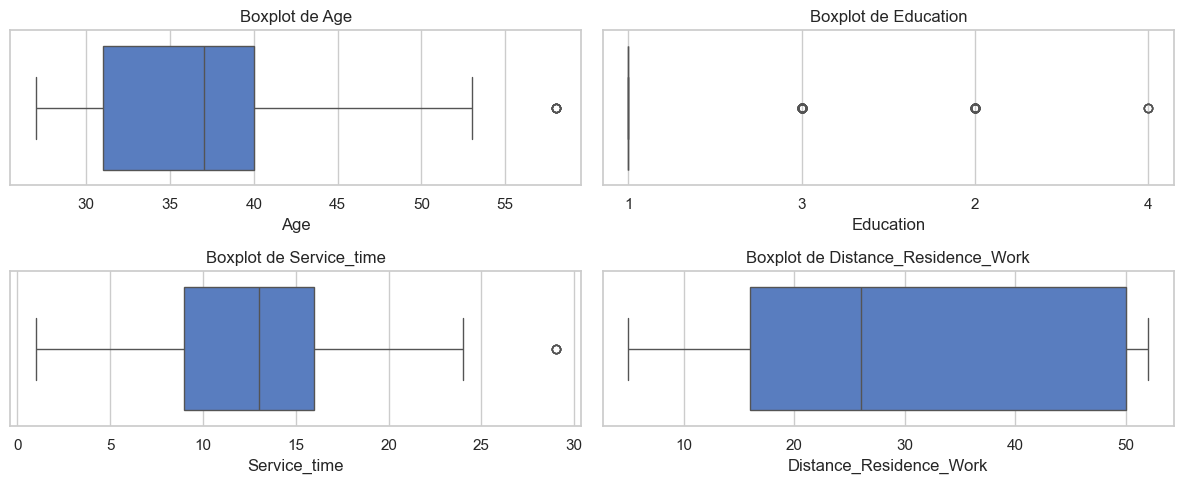

In [98]:
cols = ["Age","Education", 'Service_time', 'Distance_Residence_Work']

fig, axes = plt.subplots(2, 2, figsize=(12, 5))  # 2 filas, 2 columnas
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df_RRHH[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

In [99]:
df_RRHH[cols].dtypes

Age                         int64
Education                  object
Service_time                int64
Distance_Residence_Work     int64
dtype: object

In [100]:
# Comprobamos que hay outliers usando método IQR:
cols = ["Age", 'Service_time', 'Distance_Residence_Work'] #Education es object
for var in cols:

    q1, q3 = np.percentile(df_RRHH[var], [25, 75])
    iqr=q3-q1
    lim_inferior = q1 - 1.5 * iqr
    lim_superior = q3 + 1.5 * iqr
    print(f"\nEn la variable {var}")
    print(f"Q1:{q1}, Q3:{q3}, IQR: {iqr}")
    print(f"Limite inferior: {lim_inferior}")
    print(f"Limite superior: {lim_superior}")

outliers_iqr_var= df_RRHH[var][(df_RRHH[var] < lim_inferior) | (df_RRHH[var] > lim_superior)]
print(f"\nOutliers using IQR method: \n{outliers_iqr_var}")


En la variable Age
Q1:31.0, Q3:40.0, IQR: 9.0
Limite inferior: 17.5
Limite superior: 53.5

En la variable Service_time
Q1:9.0, Q3:16.0, IQR: 7.0
Limite inferior: -1.5
Limite superior: 26.5

En la variable Distance_Residence_Work
Q1:16.0, Q3:50.0, IQR: 34.0
Limite inferior: -35.0
Limite superior: 101.0

Outliers using IQR method: 
Series([], Name: Distance_Residence_Work, dtype: int64)


**Observaciones:**  
1) Age: serán outliers por debajo de 17.5 (raro) y por encima de 53.5
2) Antiguedad: seran outliers sólo por encima de 26.5 porque un valor negativo no tiene sentido
3)Distancia al trabajo: solo será relevante los outliers por encima de 101km porque el valor negativo no tiene sentido

**ANALISIS ABSENTISMO INICIAL**

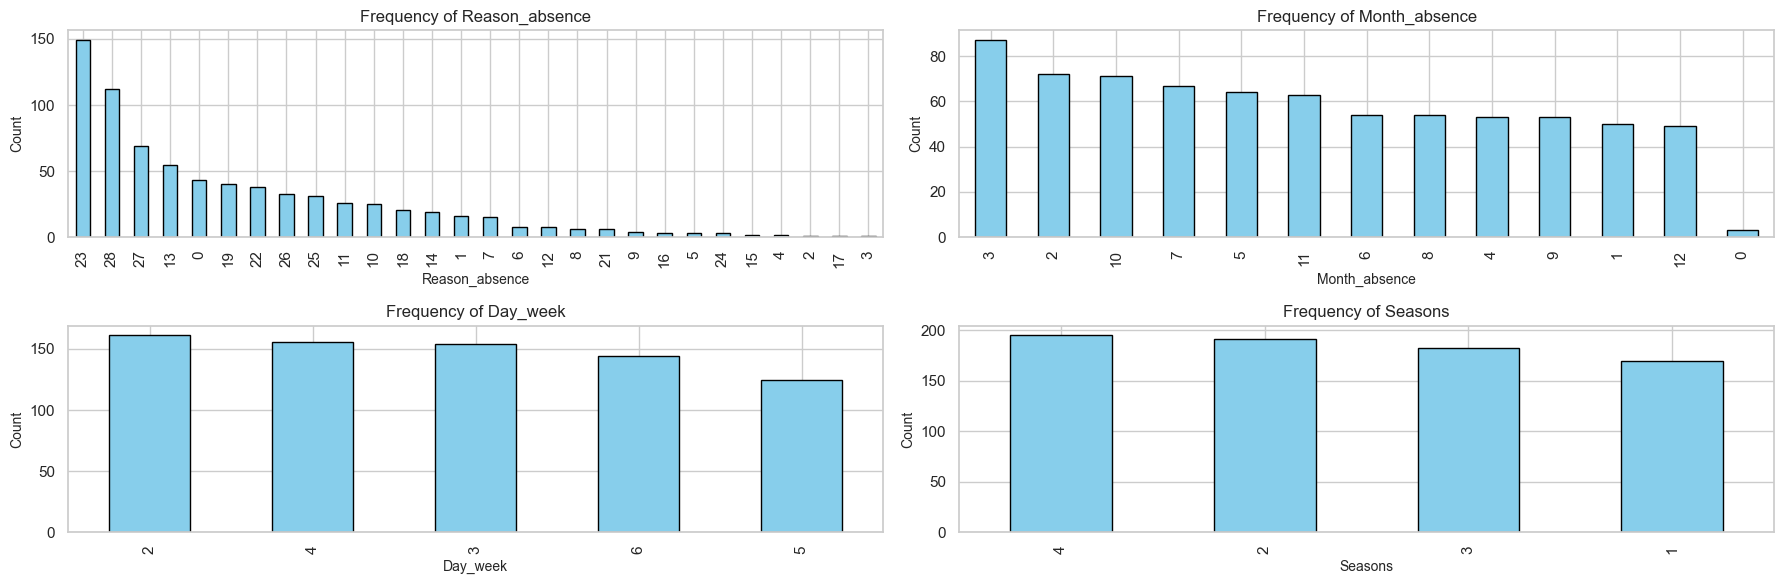

In [101]:
cols = ['Reason_absence', 'Month_absence', 'Day_week', 'Seasons']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 6))

axes = axes.flatten()  # 👈 convertir a lista de 4 posiciones

for i, col in enumerate(cols):
    freq = df_RRHH[col].value_counts()
    freq.plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    
    axes[i].set_title(f'Frequency of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**OBSERVACIONES:**  
1.- la mayor razón de absentismo es la consuslta médic(23),seguida de la visita al dentista (28) y la fisioterapia (27)  
2.- El mes de marzo concentra el mayor número se ausencias al trabajo. **Se debe eliminar el mes cero**   
3.- El dia de menor absentismo es el jueves  
4.- Apenas hay diferencia en absentismo entre las diferntes estaciones del año  

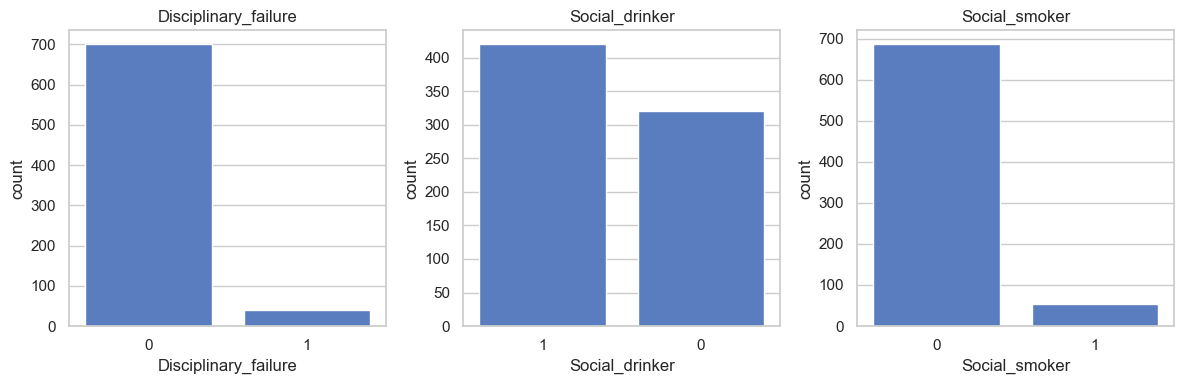

In [102]:
binary_cols = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(binary_cols):
    sns.countplot(x=df_RRHH[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Descripción estadística de las variables numéricas del dataset

In [103]:
# Estadísticas de variables numéricas nativas
resumen = df_RRHH.describe().round(2)
resumen.loc['mediana'] = df_RRHH.select_dtypes(include=[np.number]).median().round(2)

display(resumen)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Hit_target,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00
mean,18.02,19.22,6.32,3.91,2.54,221.33,29.63,12.55,36.45,94.59,79.04,172.11,26.68,6.92
std,11.02,8.43,3.44,1.42,1.11,66.95,14.84,4.38,6.48,3.78,12.88,6.03,4.29,13.33
min,1.00,0.00,0.00,2.00,1.00,118.00,5.00,1.00,27.00,81.00,56.00,163.00,19.00,0.00
25%,9.00,13.00,3.00,3.00,2.00,179.00,16.00,9.00,31.00,93.00,69.00,169.00,24.00,2.00
50%,18.00,23.00,6.00,4.00,3.00,225.00,26.00,13.00,37.00,95.00,83.00,170.00,25.00,3.00
75%,28.00,26.00,9.00,5.00,4.00,260.00,50.00,16.00,40.00,97.00,89.00,172.00,31.00,8.00
max,36.00,28.00,12.00,6.00,4.00,388.00,52.00,29.00,58.00,100.00,108.00,196.00,38.00,120.00
mediana,18.00,23.00,6.00,4.00,3.00,225.00,26.00,13.00,37.00,95.00,83.00,170.00,25.00,3.00


### Visualizaciones: Histogramas, Boxplots y Dispersión

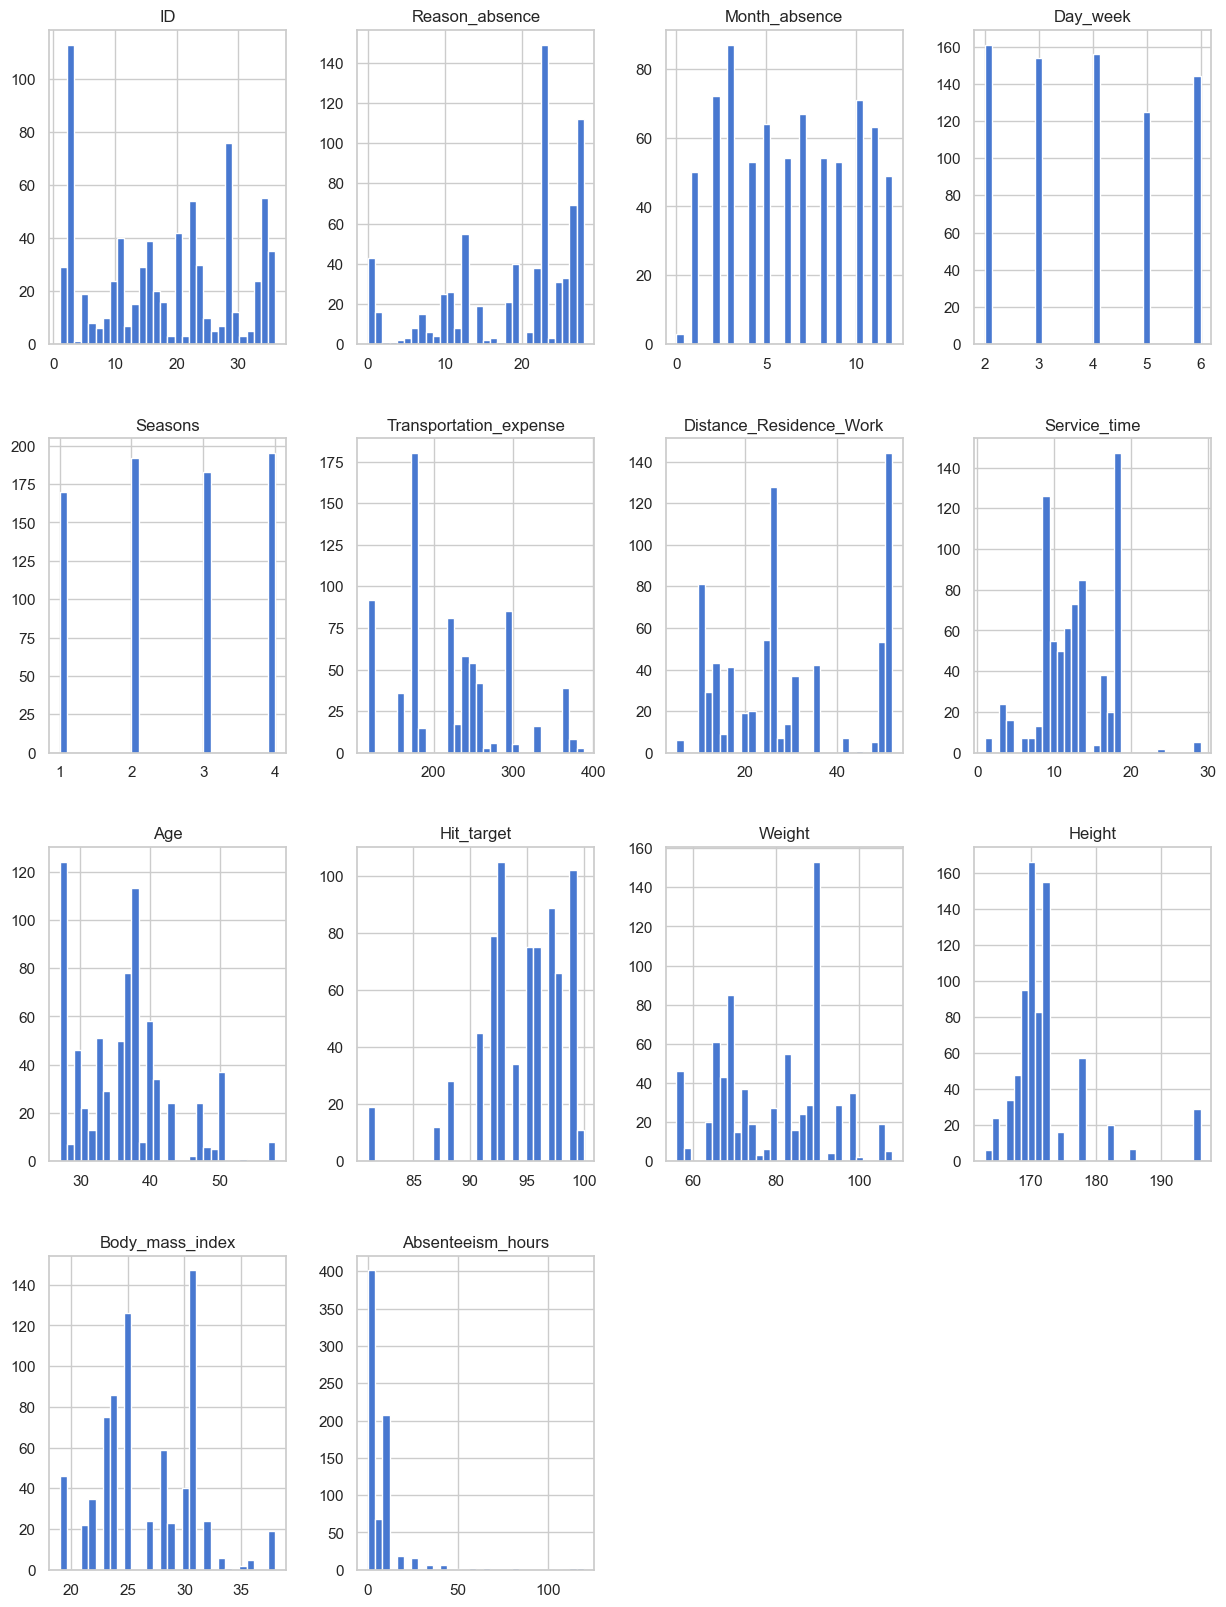

In [104]:
# Histograma de cada variable numèrica
df_RRHH.hist(bins=30, figsize=(15, 20))
plt.show()

Buscamos identificar visualmente la distribución del absentismo y la presencia de valores atípicos (outliers) que podrían sesgar futuros modelos.

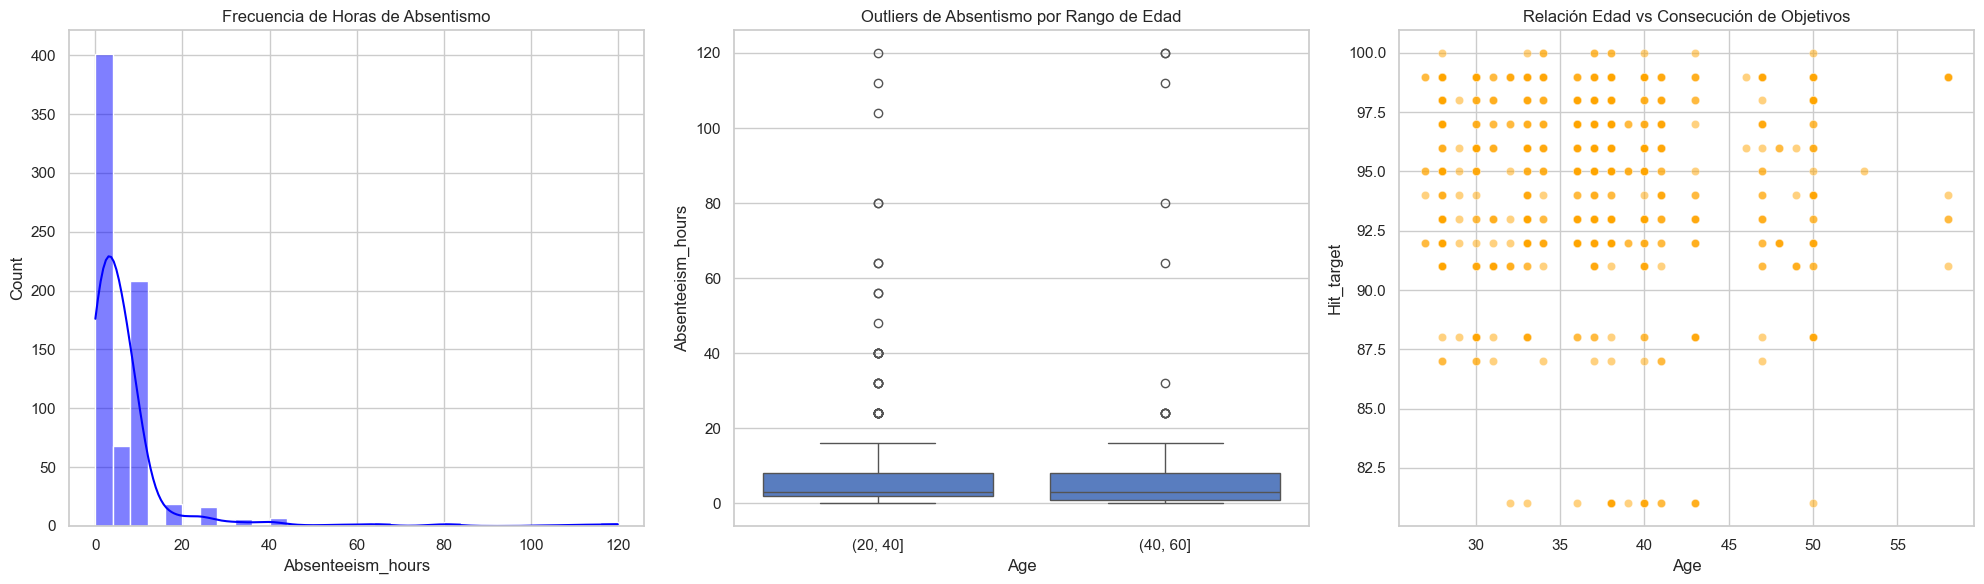

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histograma: Distribución de Horas de Absentismo
sns.histplot(df_RRHH['Absenteeism_hours'], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Frecuencia de Horas de Absentismo')

# Boxplot: Anomalías en Absentismo (Usando variable cruda Age para segmentar)
sns.boxplot(x=pd.cut(df_RRHH['Age'], bins=[20, 40, 60]), y='Absenteeism_hours', data=df_RRHH, ax=axes[1])
axes[1].set_title('Outliers de Absentismo por Rango de Edad')

# Scatter Plot: Edad vs Desempeño (Hit Target)
sns.scatterplot(x='Age', y='Hit_target', data=df_RRHH, alpha=0.5, color='orange', ax=axes[2])
axes[2].set_title('Relación Edad vs Consecución de Objetivos')

plt.tight_layout()
plt.show()

### Matriz de Correlación
Analizamos la fuerza de asociación entre las variables numéricas para identificar qué factores sociodemográficos influyen más en los resultados operativos.

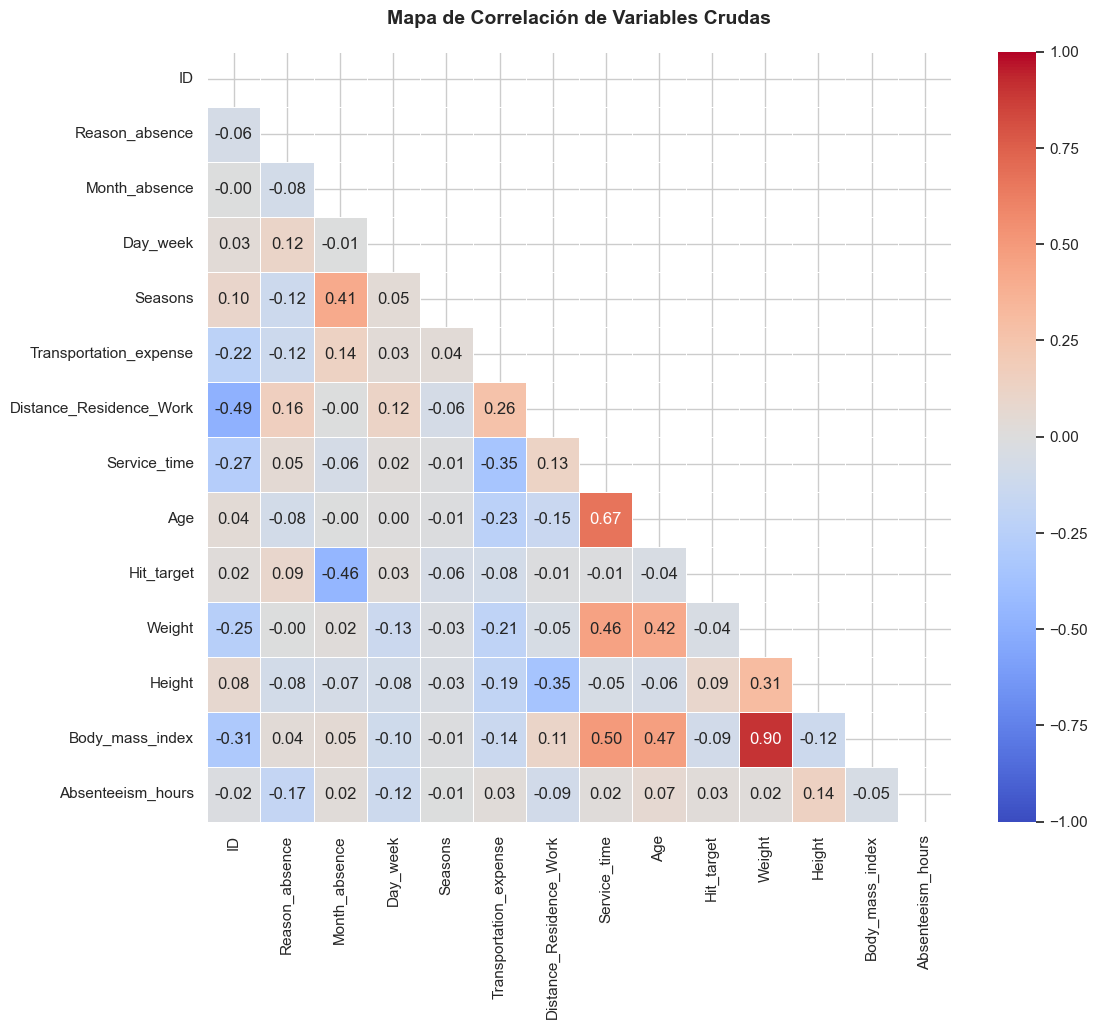

In [106]:
plt.figure(figsize=(12, 10))

# Correlación de variables numéricas disponibles
corr_matrix = df_RRHH.select_dtypes(include=[np.number]).corr()

# Máscara visual para mayor claridad (oculta el triángulo superior)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap con la escala de color corregida y centrada en 0
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1,     # Fuerza el mínimo en -1
            vmax=1,      # Fuerza el máximo en 1
            center=0,    # Fija el color neutro exactamente en el 0
            fmt=".2f", 
            linewidths=0.5)

plt.title('Mapa de Correlación de Variables Crudas', fontsize=14, fontweight='bold', pad=20)
plt.show()

### Descripción estadística para variables categoricas 

In [107]:
df_RRHH.select_dtypes(include='object').columns

Index(['Work_load_Average_day', 'Disciplinary_failure', 'Education', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet'],
      dtype='object')

**Observación:**  
1) 'Work_load_Average_day' deberia ser numérica y no la tendremos en cuneta para calcular la moda

In [108]:
cols = ['Disciplinary_failure', 'Education',
        'Son', 'Social_drinker', 'Social_smoker', 'Pet']

df_RRHH[cols].mode().iloc[0]


Disciplinary_failure    0
Education               1
Son                     0
Social_drinker          1
Social_smoker           0
Pet                     0
Name: 0, dtype: object

**Observaciones:**  
1) la mayoria no tienen sancion disciplinaria
2) la mayoria no tienen estudios superiores
3) a mayoria no tienen mascotas
4) la mayoria son bebedores sociales y no fumadores

### Conclusiones y Hallazgos del EDA (Datos Crudos)

Basándonos en las visualizaciones y las métricas extraídas en esta primera exploración, destacamos tres conclusiones fundamentales que impactan directamente en el negocio y definen nuestra hoja de ruta técnica:

**1. Bloqueo Técnico en Variables Operativas (Punto Ciego Analítico):**
* **Evidencia:** Al generar la Matriz de Correlación (Heatmap), variables críticas como la Carga de Trabajo (`Work_load_Average_day`), el Nivel Educativo (`Education`) y las Cargas Familiares (`Son`) han sido excluidas automáticamente por el motor de cálculo.
* **Causa:** El esquema de la base de datos de origen almacena estas métricas como cadenas de texto (`VARCHAR`), en gran parte debido al uso de comas decimales.
* **Impacto y Acción:** Actualmente no podemos cruzar matemáticamente el desempeño de un empleado con su volumen de trabajo asignado. Esto justifica de forma irrefutable la necesidad de ejecutar un proceso de *Data Cleaning* y transformación de tipos como paso inmediato antes de modelar los datos.

**2. El Falso Promedio: Absentismo Focalizado vs. Generalizado:**
* **Evidencia:** Tanto el Histograma como los Boxplots muestran una distribución fuertemente sesgada hacia la derecha (*right-skewed*). 
* **Impacto y Acción:** Aunque la inmensa mayoría de las ausencias operativas son de corta duración (1 a 8 horas), existen valores atípicos (*outliers*) extremos que superan las 100 y 120 horas. Esto significa que la "media de horas perdidas" de la empresa está inflada artificialmente por unos pocos casos crónicos. El problema de Rapid Express no es una cultura generalizada de absentismo, sino incidencias médicas o disciplinarias de larga duración muy localizadas que el departamento de Bienestar deberá gestionar caso a caso.

**3. Retención de Talento (El Perfil "Leal"):**
* **Evidencia:** El mapa de correlación de Pearson demuestra una relación positiva fuerte (0.67) entre la Edad del empleado (`Age`) y su Tiempo de Servicio (`Service_time`).
* **Impacto y Acción:** Esto se traduce en una tasa de rotación de personal muy baja. Rapid Express cuenta con una plantilla madura que "hace carrera" dentro de la compañía. Desde la perspectiva de Perfil y Desempeño, esto es una excelente noticia: cualquier inversión económica que hagamos en formación (*Upskilling* para los niveles educativos básicos) tendrá un alto retorno de inversión (ROI), ya que sabemos que el talento no se marchará a la competencia a corto plazo.

---
Próximos pasos (tablero Kanban):
--- 
Solicitamos revisión del equipo (*In Review*) para dar por finalizado este EDA sobre datos crudos y continuar con el ticket de **Data Cleaning**, donde limpiaremos los formatos `VARCHAR` y decidiremos la estrategia de imputación para consolidar el dataset final.